In [3]:
pip install peakweather

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [4]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd

In [5]:
import peakweather
print(peakweather.__version__)
from peakweather import PeakWeatherDataset

0.2.2


In [6]:
from peakweather.dataset import PeakWeatherDataset
ds = PeakWeatherDataset(root=None)

stations.parquet: 57.3kB [00:00, 202kB/s]                             
installation.parquet: 90.1kB [00:00, 426kB/s]                             
parameters.parquet: 8.19kB [00:00, 44.4kB/s]
disclaimer.txt: 8.19kB [00:00, 46.8kB/s]
2017.parquet: 56.9MB [00:00, 152MB/s]                             
2018.parquet: 57.3MB [00:00, 155MB/s]                             
2019.parquet: 57.5MB [00:00, 153MB/s]                             
2020.parquet: 57.1MB [00:00, 118MB/s]                             
2021.parquet: 56.5MB [00:00, 153MB/s]                             
2022.parquet: 56.8MB [00:00, 136MB/s]                             
2023.parquet: 57.5MB [00:00, 135MB/s]                             
2024.parquet: 57.5MB [00:00, 154MB/s]                             
2025.parquet: 45.1MB [00:00, 136MB/s]                             


In [ ]:
dataset = PeakWeatherDataset()
df, mask = dataset.get_observations(
    parameters=["temperature"],  # list of weather parameters
    first_date="2014-01-01 00:01",
    last_date="2025-12-31 23:59",
    return_mask=True,
)

df.head()

nat_abbr,ABE,ABO,AEG,AFI,AGATT,AGSTE,AIE,AIG,AIR,ALS,...,WEE,WFJ,WHF,WIN,WIT,WYN,ZER,ZEV,ZWE,ZWK
name,temperature,temperature,temperature,temperature,temperature,temperature,temperature,temperature,temperature,temperature,...,temperature,temperature,temperature,temperature,temperature,temperature,temperature,temperature,temperature,temperature
datetime,,,,,,,,,,,,,,,,,,,,,
2017-01-01 00:00:00+00:00,0.0,1.1,0.0,0.0,0.0,0.0,0.0,-4.7,0.0,0.0,...,0.0,-3.2,0.0,0.0,0.0,-3.0,-3.5,0.0,-8.0,0.0
2017-01-01 00:10:00+00:00,0.0,1.2,0.0,0.0,0.0,0.0,0.0,-5.4,0.0,0.0,...,0.0,-3.2,0.0,0.0,0.0,-3.0,-2.8,0.0,-7.5,0.0
2017-01-01 00:20:00+00:00,0.0,1.2,0.0,0.0,0.0,0.0,0.0,-4.8,0.0,0.0,...,0.0,-3.3,0.0,0.0,0.0,-3.2,-3.5,0.0,-8.3,0.0
2017-01-01 00:30:00+00:00,0.0,2.0,0.0,0.0,0.0,0.0,0.0,-4.8,0.0,0.0,...,0.0,-3.5,0.0,0.0,0.0,-3.2,-3.2,0.0,-7.2,0.0
2017-01-01 00:40:00+00:00,0.0,0.5,0.0,0.0,0.0,0.0,0.0,-4.7,0.0,0.0,...,0.0,-3.3,0.0,0.0,0.0,-3.1,-3.4,0.0,-8.1,0.0


In [14]:
dataset_hourly = PeakWeatherDataset(
    freq="h",
    aggregation_methods={"temperature": "mean"},
)
dfh, mask = dataset_hourly.get_observations(
    parameters=["temperature"],  # list of weather parameters
    first_date="2014-01-01 00:01",
    last_date="2025-12-31 23:59",
    return_mask=True,
)

dfh.head()

nat_abbr,ABE,ABO,AEG,AFI,AGATT,AGSTE,AIE,AIG,AIR,ALS,...,WEE,WFJ,WHF,WIN,WIT,WYN,ZER,ZEV,ZWE,ZWK
name,temperature,temperature,temperature,temperature,temperature,temperature,temperature,temperature,temperature,temperature,...,temperature,temperature,temperature,temperature,temperature,temperature,temperature,temperature,temperature,temperature
datetime,,,,,,,,,,,,,,,,,,,,,
2017-01-01 00:00:00+00:00,0.0,1.100000,0.0,0.0,0.0,0.0,0.0,-4.700000,0.0,0.0,...,0.0,-3.200000,0.0,0.0,0.0,-3.000000,-3.500000,0.0,-8.000000,0.0
2017-01-01 01:00:00+00:00,0.0,1.316667,0.0,0.0,0.0,0.0,0.0,-5.016667,0.0,0.0,...,0.0,-3.350000,0.0,0.0,0.0,-3.133333,-3.383333,0.0,-8.033334,0.0
2017-01-01 02:00:00+00:00,0.0,0.833333,0.0,0.0,0.0,0.0,0.0,-5.333333,0.0,0.0,...,0.0,-3.500000,0.0,0.0,0.0,-3.033334,-3.833333,0.0,-8.450000,0.0
2017-01-01 03:00:00+00:00,0.0,0.766667,0.0,0.0,0.0,0.0,0.0,-5.516666,0.0,0.0,...,0.0,-3.283334,0.0,0.0,0.0,-3.166667,-3.733333,0.0,-8.933333,0.0
2017-01-01 04:00:00+00:00,0.0,1.150000,0.0,0.0,0.0,0.0,0.0,-5.566667,0.0,0.0,...,0.0,-3.766667,0.0,0.0,0.0,-3.233333,-3.550000,0.0,-8.883333,0.0


In [9]:
def plot_weather_parameters(df, stations, parameters):
    fig, ax = plt.subplots(len(parameters))

    time_freq = mdates.date2num(df.index[1]) - mdates.date2num(df.index[0])
    time_freq_minutes = int(time_freq * 24 * 60)

    colors = matplotlib.colormaps["tab10"]
    if len(parameters) == 1:
        ax = [ax]
    
    for i, param in enumerate(parameters):
        for station in stations:
            ax[i].plot(
                df.index,
                df[station, param],
                label=f"{station} {param}",
                color=colors(stations.index(station)),
                alpha=0.5,
            )
        ax[i].set_title(f"{param.capitalize()} ({time_freq_minutes} min)")
        ax[i].set_ylabel(f"{param.capitalize()} ({dataset.parameters_table['unit'][param]})")
        ax[i].legend()
        ax[i].grid(True)

    plt.tight_layout()
    plt.show()

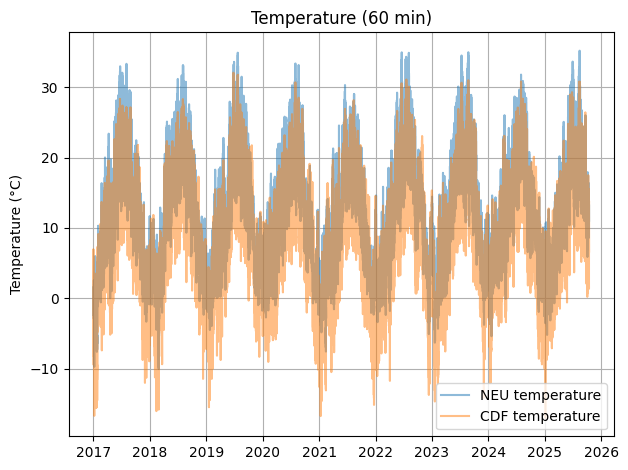

In [15]:
plot_weather_parameters(dfh, stations=["NEU", "CDF"], parameters=["temperature"])

In [17]:
dataset.stations_table["station_name"]

nat_abbr
ABE          Aarberg
ABO        Adelboden
AEG        Oberägeri
AFI      Andelfingen
AGATT       Attelwil
            ...     
WYN            Wynau
ZER          Zermatt
ZEV        Zervreila
ZWE       Zweisimmen
ZWK        Zwillikon
Name: station_name, Length: 302, dtype: object

In [12]:
def plot_temperature_by_station(df, stations):
    param = "temperature"
    fig, ax = plt.subplots(len(stations), figsize=(12, 4 * len(stations)))
    time_freq = mdates.date2num(df.index[1]) - mdates.date2num(df.index[0])
    time_freq_minutes = int(time_freq * 24 * 60)

    # Handle case where there's only one station (ax won't be a list)
    if len(stations) == 1:
        ax = [ax]

    for i, station in enumerate(stations):
        ax[i].plot(
            df.index,
            df[station, param],
            label=f"{station}",
            color="tab:red",
            alpha=0.5,
        )
        ax[i].set_title(f"{station} — Temperature ({time_freq_minutes} min)")
        ax[i].set_ylabel(f"Temperature ({dataset.parameters_table['unit'][param]})")
        ax[i].legend()
        ax[i].grid(True)

    plt.tight_layout()
    plt.show()

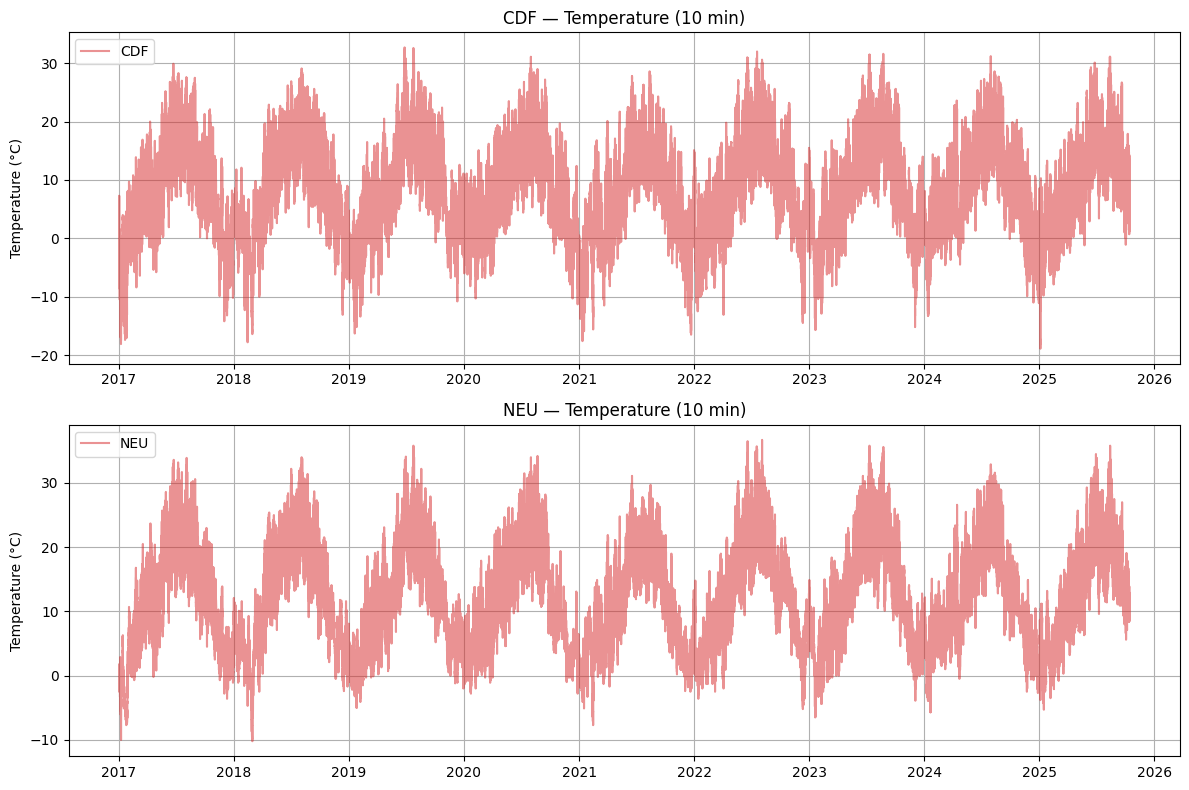

In [13]:
plot_temperature_by_station(df, stations=["CDF","NEU"])

In [16]:
zero_counts_hourly = (dfh.xs("temperature", axis=1, level=1) == 0).sum()
with pd.option_context("display.max_rows", None):
    print(zero_counts_hourly)

nat_abbr
ABE      76993
ABO         64
AEG      76993
AFI      76993
AGATT    76993
AGSTE    76993
AIE      76993
AIG         17
AIR      76993
ALS      76993
ALT         13
AMW      76993
AND         65
ANT         28
APP      76993
ARH         54
ARO         78
ATT        568
AUB      76993
AVA      76993
BAN      76993
BAS         68
BAW      76993
BEC      76993
BEH        592
BEP      76993
BER         40
BEX      76993
BEY      76993
BEZ        122
BIA       5709
BIE         72
BIN        142
BIV        165
BIZ        136
BLA       3339
BLZ      76993
BOL         33
BOS      76993
BOU         15
BRI      76993
BRL         36
BRP      76993
BRT      76993
BRW      76993
BRZ      76993
BUE      76993
BUF         68
BUS         52
CDF         50
CDM        204
CEV         16
CGI         24
CHA        901
CHB         60
CHD        181
CHM         83
CHU         31
CHZ        501
CIM        159
CMA        207
COL      76993
COM        663
COS      76993
COU      76993
COV        334
C

In [23]:
def max_consecutive_zeros(series):
    mask = series == 0
    streaks = mask * (mask.groupby((~mask).cumsum()).cumcount() + 1)
    max_streak = streaks.max()
    # Find the end index of the max streak, then walk back to get the start
    end_idx = streaks.idxmax()
    start_idx = series.index[series.index.get_loc(end_idx) - max_streak + 1]
    return max_streak, start_idx

temp_df = df.xs("temperature", axis=1, level=1)

consecutive = temp_df.apply(max_consecutive_zeros)
# apply returns a DataFrame with one row per return value, transpose for clarity
consecutive = consecutive.T
consecutive.columns = ["max_streak", "start_date"]
consecutive = consecutive[consecutive["max_streak"] >= 6].sort_values("max_streak", ascending=False)

print("Stations with at least 6 consecutive zero temperatures:\n")
for station, row in consecutive.iterrows():
    print(f"  {station}: {int(row['max_streak'])} consecutive zeros starting {row['start_date']}")

Stations with at least 6 consecutive zero temperatures:

  ABE: 461952 consecutive zeros starting 2017-01-01 00:00:00+00:00
  MGL: 461952 consecutive zeros starting 2017-01-01 00:00:00+00:00
  LOH: 461952 consecutive zeros starting 2017-01-01 00:00:00+00:00
  LON: 461952 consecutive zeros starting 2017-01-01 00:00:00+00:00
  LSN: 461952 consecutive zeros starting 2017-01-01 00:00:00+00:00
  LTB: 461952 consecutive zeros starting 2017-01-01 00:00:00+00:00
  MAB: 461952 consecutive zeros starting 2017-01-01 00:00:00+00:00
  MAT: 461952 consecutive zeros starting 2017-01-01 00:00:00+00:00
  MEV: 461952 consecutive zeros starting 2017-01-01 00:00:00+00:00
  MMO: 461952 consecutive zeros starting 2017-01-01 00:00:00+00:00
  LEU: 461952 consecutive zeros starting 2017-01-01 00:00:00+00:00
  MSG: 461952 consecutive zeros starting 2017-01-01 00:00:00+00:00
  MSK: 461952 consecutive zeros starting 2017-01-01 00:00:00+00:00
  MUR: 461952 consecutive zeros starting 2017-01-01 00:00:00+00:00
  NEB

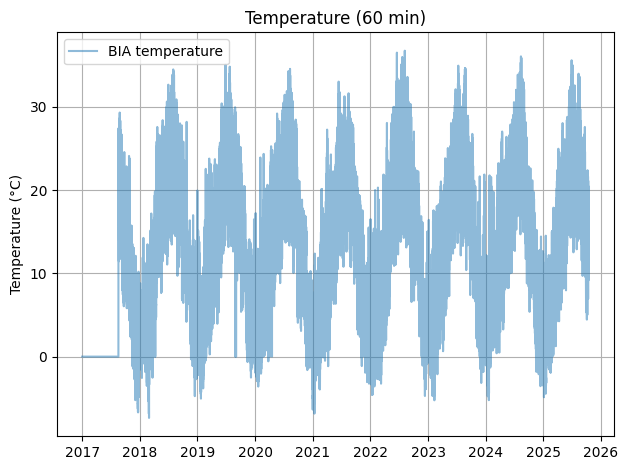

In [21]:
plot_weather_parameters(dfh, stations=["BIA"], parameters=["temperature"])

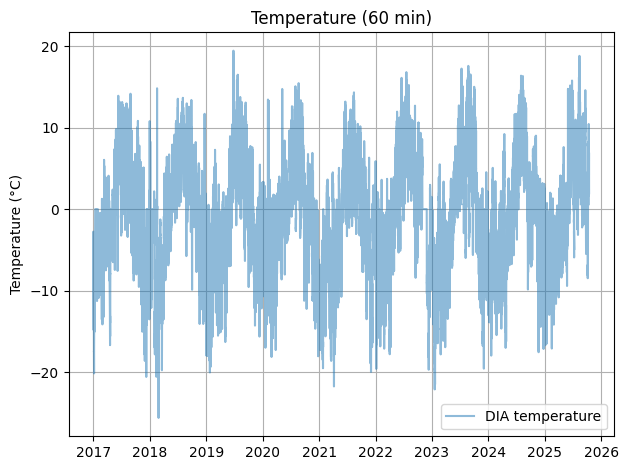

In [22]:
plot_weather_parameters(dfh, stations=["DIA"], parameters=["temperature"])